Dataset shape: (1100, 10)

Sleep Quality distribution:
Sleep Quality
Good    695
Bad     405
Name: count, dtype: int64
=== Descriptive Statistics ===
               Age  Daily Screen Time
count  1100.000000        1100.000000
mean     34.813636           6.389091
std      11.990320           2.650986
min      15.000000           2.000000
25%      24.000000           4.000000
50%      35.000000           6.000000
75%      45.000000           8.000000
max      55.000000          12.000000


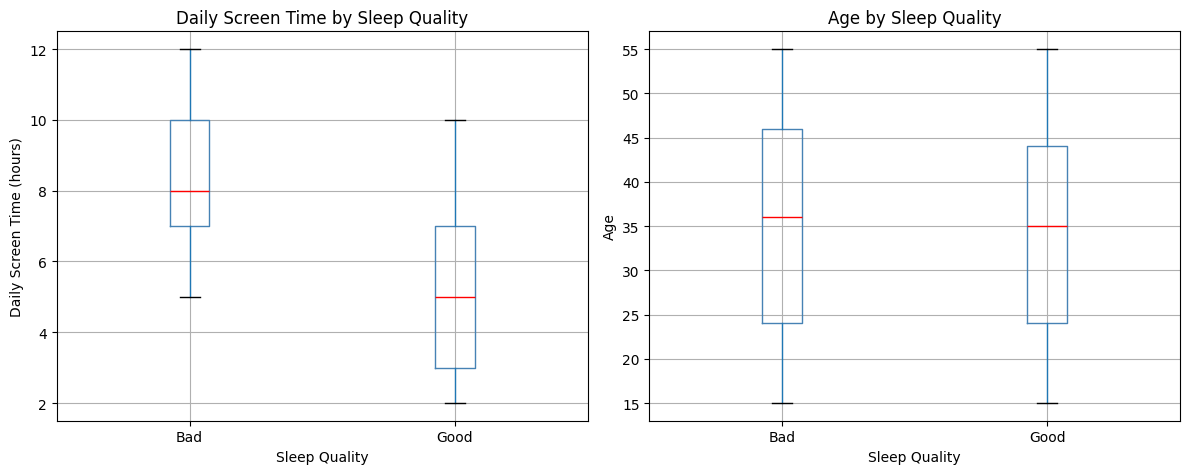


=== Mean Daily Screen Time by Sleep Quality ===
Sleep Quality
Bad     8.306173
Good    5.271942
Name: Daily Screen Time, dtype: float64

=== Mean Age by Sleep Quality ===
Sleep Quality
Bad     35.177778
Good    34.601439
Name: Age, dtype: float64
=== Descriptive Statistics by Sleep Quality ===
               Age Mean  Age Median  Age Std  Age Min  Age Max  Daily Screen Time Mean  Daily Screen Time Median  Daily Screen Time Std  Daily Screen Time Min  Daily Screen Time Max
Sleep Quality                                                                                                                                                                        
Bad               35.18        36.0    12.08       15       55                    8.31                       8.0                   1.99                      5                     12
Good              34.60        35.0    11.94       15       55                    5.27                       5.0                   2.33                      2

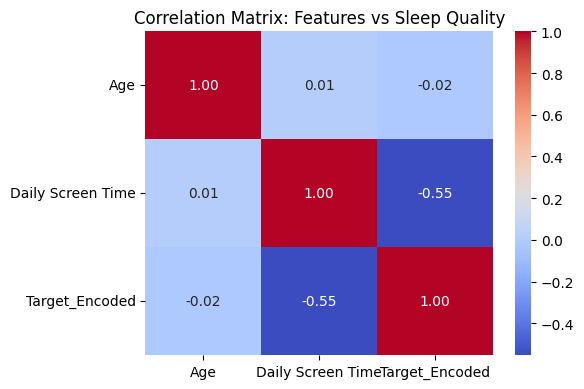

=== Independent Samples T-Test: Daily Screen Time by Sleep Quality ===
  Bad  Sleep Mean:  8.31 hrs
  Good Sleep Mean:  5.27 hrs
  T-Statistic:      21.9524
  P-Value:          0.000000
  Result: Statistically significant (p < 0.05)

=== Independent Samples T-Test: Age by Sleep Quality ===
  Bad  Sleep Mean:  35.18 yrs
  Good Sleep Mean:  34.60 yrs
  T-Statistic:      0.7688
  P-Value:          0.442202
  Result: Not significant (p >= 0.05)
Classes: ['Bad' 'Good']
Training samples: 880
Test samples:     220


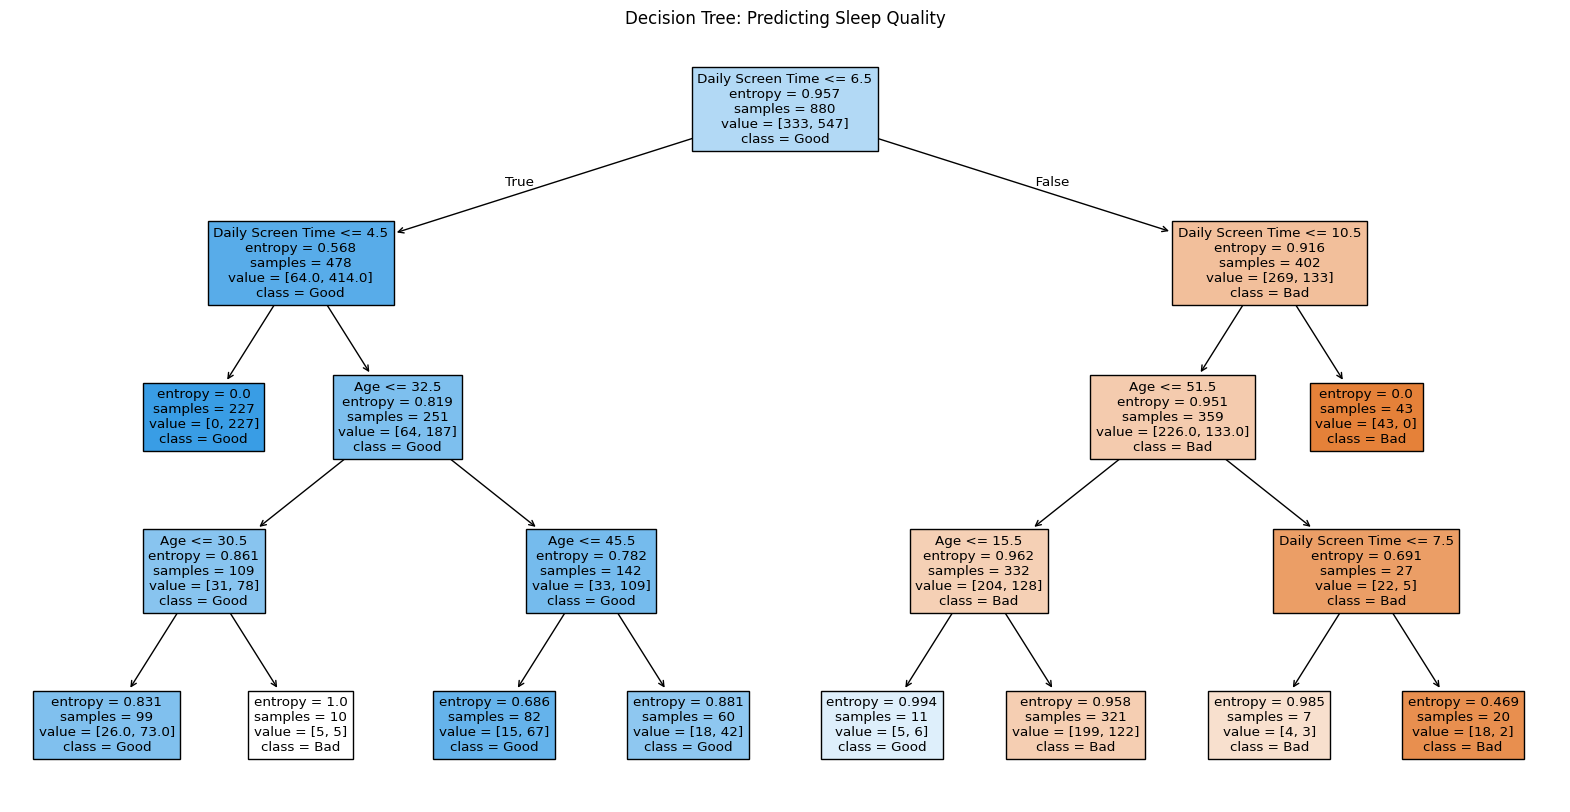

Accuracy: 0.7227272727272728
Precision per category: [0.55445545 0.86554622]
Recall per category:    [0.77777778 0.69594595]
F1-score per category:  [0.64739884 0.77153558]

=== Full Classification Report ===
              precision    recall  f1-score   support

         Bad       0.55      0.78      0.65        72
        Good       0.87      0.70      0.77       148

    accuracy                           0.72       220
   macro avg       0.71      0.74      0.71       220
weighted avg       0.76      0.72      0.73       220

=== Model Performance Summary ===

           Class Precision Recall F1-Score Support
             Bad     0.554  0.778    0.647      72
            Good     0.866  0.696    0.772     148
               —         —      —        —       —
    Weighted Avg     0.764  0.723    0.731     220
Overall Accuracy         —      —    0.723     220


In [ ]:
# BME3053C - Computer Applications in BME
# Spring 2026
# Team Name: Screen Time & Sleep
# Vikram Saxena, Micah Vennard, Akhil Kandamkulathy, Jesse Zelahy

# Analyzing the Impact of Screen Time on Sleep Duration


# Download Kaggle Dataset
import pandas as pd

url = 'https://www.dropbox.com/scl/fi/ca4rwi9c46go5smt91qzr/Impact-of-Digital-Device-Usage-on-Sleep-Quality-and-Mental-Health.csv?rlkey=425n91pim8dt7bx8uom60c0bj&st=i6zbihlj&dl=1'

df = pd.read_csv(url)
df.head()

# 1. Prepare Data
df = df.dropna(subset=['Age', 'Daily Screen Time', 'Sleep Quality'])

print("Dataset shape:", df.shape)
print("\nSleep Quality distribution:")
print(df['Sleep Quality'].value_counts())

  # 63% Good sleepers, 37% Bad sleepers

# 2. Perform Statistical Analysis using Age and Daily Screen Time as Features
print("=== Descriptive Statistics ===")
print(df[['Age', 'Daily Screen Time']].describe())
  # Boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Daily Screen Time by Sleep Quality
df.boxplot(column='Daily Screen Time', by='Sleep Quality', ax=axes[0],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[0].set_title('Daily Screen Time by Sleep Quality')
axes[0].set_xlabel('Sleep Quality')
axes[0].set_ylabel('Daily Screen Time (hours)')

    # Age by Sleep Quality
df.boxplot(column='Age', by='Sleep Quality', ax=axes[1],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[1].set_title('Age by Sleep Quality')
axes[1].set_xlabel('Sleep Quality')
axes[1].set_ylabel('Age')

plt.suptitle('')
plt.tight_layout()
plt.show()

  # Relationship Stats

print("\n=== Mean Daily Screen Time by Sleep Quality ===")
print(df.groupby('Sleep Quality')['Daily Screen Time'].mean())

print("\n=== Mean Age by Sleep Quality ===")
print(df.groupby('Sleep Quality')['Age'].mean())

    # Statistical Tests
from scipy import stats

      # Split into two groups by Sleep Quality
bad_sleep  = df[df['Sleep Quality'] == 'Bad']
good_sleep = df[df['Sleep Quality'] == 'Good']

      # ST:
t_stat_screen, p_val_screen = stats.ttest_ind(
    bad_sleep['Daily Screen Time'],
    good_sleep['Daily Screen Time']
)

print("=== Independent Samples T-Test: Daily Screen Time by Sleep Quality ===")
print(f"  Bad  Sleep Mean:  {bad_sleep['Daily Screen Time'].mean():.2f} hrs")
print(f"  Good Sleep Mean:  {good_sleep['Daily Screen Time'].mean():.2f} hrs")
print(f"  T-Statistic:      {t_stat_screen:.4f}")
print(f"  P-Value:          {p_val_screen:.6f}")
print(f"  Result: {'Statistically significant (p < 0.05)' if p_val_screen < 0.05 else 'Not significant (p >= 0.05)'}")

print()

      # Age:
t_stat_age, p_val_age = stats.ttest_ind(
    bad_sleep['Age'],
    good_sleep['Age']
)

print("=== Independent Samples T-Test: Age by Sleep Quality ===")
print(f"  Bad  Sleep Mean:  {bad_sleep['Age'].mean():.2f} yrs")
print(f"  Good Sleep Mean:  {good_sleep['Age'].mean():.2f} yrs")
print(f"  T-Statistic:      {t_stat_age:.4f}")
print(f"  P-Value:          {p_val_age:.6f}")
print(f"  Result: {'Statistically significant (p < 0.05)' if p_val_age < 0.05 else 'Not significant (p >= 0.05)'}")


# Mean Screen Time for Poor Sleepers (5.3 hrs) vs Good Sleepers (8.3 hrs)
# --> different

# Mean Age for Poor Sleepers (35.2 yo) vs Good Sleepers (34.6 yo)
# --> carries little meaning

# 3. Run Correlation Heatmap with our Two Factors
import matplotlib.pyplot as plt
import seaborn as sns

# Encode target numerically for correlation only
df['Target_Encoded'] = df['Sleep Quality'].map({'Good': 1, 'Bad': 0})

corr = df[['Age', 'Daily Screen Time', 'Target_Encoded']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Features vs Sleep Quality')
plt.tight_layout()
plt.show()

# ST: moderate negative relationship (r=-0.55)
# Age: no relationship (r=-0.02)
# Supports statistical analysis

# 4. Feature Selection
from sklearn.preprocessing import LabelEncoder

# Features: Age and Daily Screen Time only (per methodology)
X = df[['Age', 'Daily Screen Time']]

le = LabelEncoder()
y = le.fit_transform(df['Sleep Quality'])

print("Classes:", le.classes_)  # 0 = Bad, 1 = Good

# 5. Test/Train Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training samples:", len(X_train))
print("Test samples:    ", len(X_test))

# 6. Model - Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_model = DecisionTreeClassifier(
    criterion='entropy',
    min_samples_split=15,
    max_depth=4,
    random_state=42
)
dt_model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns.tolist(),
          class_names=le.classes_, filled=True)
plt.title('Decision Tree: Predicting Sleep Quality')
plt.show()

# DTC with entropy --> most important split is at ST <= 6.5hrs
# Over or under 6.5 hours may be a strong indicator of poor or good sleep.

# 7. Evaluate Model Accuracy
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

y_pred = dt_model.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average=None)
recall    = recall_score(y_test, y_pred, average=None)
f1        = f1_score(y_test, y_pred, average=None)

print("Accuracy:", accuracy)
print("Precision per category:", precision)
print("Recall per category:   ", recall)
print("F1-score per category: ", f1)

print("\n=== Full Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# We evaluate this DTC using the test data
# 72.3% overall accuracy
# Correctly identify 78% of Bad sleepers, low precision likely due to only 37% bad
# 87% of Predicted Good are accurate
